In [1]:
# Image classification on Fashion MNIST or CIFAR-10

In [2]:
# Applying CNN architecture to a larger Dataset
# Larger Datasets:
    # -Larger datasets like cifar-10 or fashion MNIST represent more realistic and diverse challenges compared to toy datasets like MNIST
    # -They require deeper architecture, careful regularization, and augmentation for optimal performance


# Experimenting with Architecture design, Regularization, and Augmentation

# key Techniques to improve performance:
    # 1.Architecture Modifications:
        # -Add more convolutional layers or change kernal sizes
        # -Use more filters in deeper layers to capture complex features
    # 2.Regularization:
        # -Apply dropout in dense layers and batch normalization in convolutional layers
        # -Prevent overfitting in deeper models
    # 3. Data Augmentation:
        # -Use techniques like random filliping, cropping, and rotation to improve generalization
        

In [3]:
# Analyzing Model performance:

# Evaluation Metrics:
    # -Accuracy: overall classification correctioness
    # -Loss: Measures the difference between predictions and ground truth
    # -Confusion Matrix: Highlights misclassified classes for deeper insights


In [1]:
# project: Objective:
    # Build, train, and optimize a CNN for Fashion MNIST or CIFAR-10 image classification,/
    # experimenting with regularization and data augmentation to achieve best performance

c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


 training data size:50000
 testing data size:10000
EnhancedCNN(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2304, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
epoch 1, loss: 1.805276507459333
epoch 2, loss: 1.6155138370935873
epoch 3, loss: 1.5444365450183448
epoch 4, loss: 1.4944285038487075
epoch 5, loss: 1.4649453811023547
epoch 6, loss: 1.425677055593037
epoch 7, loss: 1.4095615706480373
epoch 8, loss: 1.3832323846914578
epoch 9, loss: 1.3686748189694435
epoch 10, loss: 1.3487

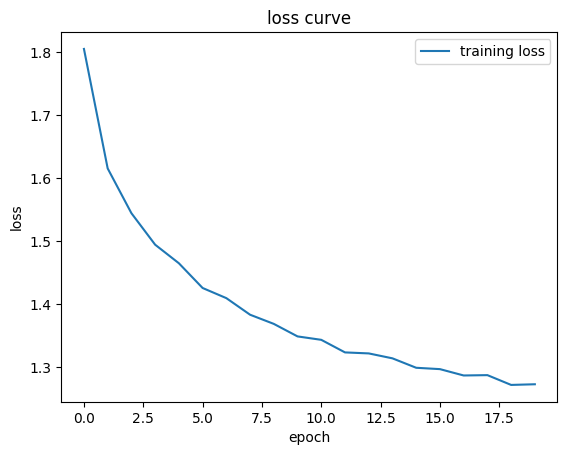

In [4]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# define the transformations
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# get loader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f" training data size:{len(train_dataset)}")
print(f" testing data size:{len(test_dataset)}")

# enchance the CNN
class EnhancedCNN(nn.Module):
    def __init__(self):
        super(EnhancedCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.5)

        # calculate the size of the output from the convolutional layer dynamically
        self._calculate_conv_output()

        self.fc1 = nn.Linear(self.conv_output_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)


    def _calculate_conv_output(self):
        # Dummy input tensor with same size as the input images
        dummy_input = torch.zeros(1, 3, 32, 32)
        with torch.no_grad():
            output = self.pool(F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(dummy_input)))))))
        self.conv_output_size = output.numel()

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    
model = EnhancedCNN()
print(model)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

training_loss = []

# training loop
def train_model(model, train_loader, criterion, optimizer, epochs=20):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)
        training_loss.append(epoch_loss)
        print(f"epoch {epoch+1}, loss: {epoch_loss:}")
    
train_model(model, train_loader, criterion, optimizer)

# evaluating the model
def evaluate_model(model, test_loader):
    model.eval()
    correct=0
    total=0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"test accuracy: {100 * correct / total: .2f}%")

evaluate_model(model, test_loader)

# plot 
import matplotlib.pyplot as plt

plt.plot(training_loss, label="training loss")
plt.title("loss curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [12]:
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Define the transformations
# FashionMNIST is grayscale (1 channel) → use single-value Normalize
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),          # ✅ Bug 1 fixed: 1-channel normalize
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),           # ✅ Bug 1 fixed
])

# Load FashionMNIST dataset                         # ✅ Bug 5 fixed: corrected comment
train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform_train)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training data size: {len(train_dataset)}")
print(f"Testing data size:  {len(test_dataset)}")


class EnhancedCNN(nn.Module):
    def __init__(self):
        super(EnhancedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)             # ✅ Bug 1 fixed: 1 input channel
        self.bn1   = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.bn2   = nn.BatchNorm2d(16)
        self.pool  = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self._calculate_conv_output()                # fixed typo in method name too

        self.fc1 = nn.Linear(self.conv_output_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def _calculate_conv_output(self):
        dummy_input = torch.zeros(1, 1, 32, 32)     # 1-channel dummy input
        with torch.no_grad():
            x = self.pool(F.relu(self.bn1(self.conv1(dummy_input))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
        self.conv_output_size = x.numel()

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # ✅ Bug 2 fixed: block 1
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # ✅ Bug 2 fixed: block 2
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = EnhancedCNN()
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
training_loss = []

def train_model(model, train_loader, criterion, optimizer, epochs=20):  # ✅ Bug 4 fixed: param name
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_loss = running_loss / len(train_loader)
        training_loss.append(epoch_loss)
        print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

train_model(model, train_loader, criterion, optimizer)


def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:           # ✅ Bug 3 fixed: 'labels' not 'label'
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    print(f"Test Accuracy: {100 * correct / total:.2f}%")

evaluate_model(model, test_loader)

import matplotlib.pyplot as plt
plt.plot(training_loss, label="Training Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Training data size: 60000
Testing data size:  10000
EnhancedCNN(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (bn1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Epoch 1, Loss: 0.7464
Epoch 2, Loss: 0.5308


KeyboardInterrupt: 